# Análisis de Supervivencia en el Titanic - Clasificación

Este notebook realiza un análisis completo del dataset del Titanic con el objetivo de predecir si un pasajero sobrevivió o no. Utilizamos múltiples algoritmos de clasificación para comparar su rendimiento.

## Contenido:
1. **Importación de librerías** - Carga de herramientas necesarias
2. **Carga y exploración de datos** - Análisis inicial del dataset
3. **Visualización de datos** - Gráficos para entender las relaciones
4. **Preparación de datos** - One-hot encoding y manejo de valores faltantes
5. **Entrenamiento de modelos** - Regresión logística, árboles, Random Forest y KNeighbors
6. **Evaluación** - Comparación de métricas de rendimiento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importación de Librerías

Se importan las siguientes librerías esenciales:
- **pandas**: Para manipulación y análisis de datos en formato de DataFrames
- **matplotlib**: Librería de visualización de gráficos 2D
- **seaborn**: Librería de visualización estadística basada en matplotlib, proporciona gráficos más atractivos y complejos

In [2]:
data = pd.read_csv('data/titanic3.csv')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Carga y Exploración Inicial de Datos

Cargamos el archivo CSV del Titanic con pandas y mostramos las primeras 5 filas para entender la estructura del dataset.

In [3]:
data.shape

(1309, 14)

Mostramos la forma del dataset (número de filas y columnas):

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


Obtener información detallada del dataset: nombres de columnas, tipos de datos y valores faltantes (null):

Para la siguiente informacion se tomara 0 como no y 1 como si

In [5]:
data['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

## 3. Análisis Exploratorio - Variable Objetivo

Analizamos la distribución de la variable objetivo "survived" (si el pasajero sobrevivió: 0=No, 1=Sí). Contamos cuántos pasajeros cayeron en cada categoría:

<Axes: xlabel='survived'>

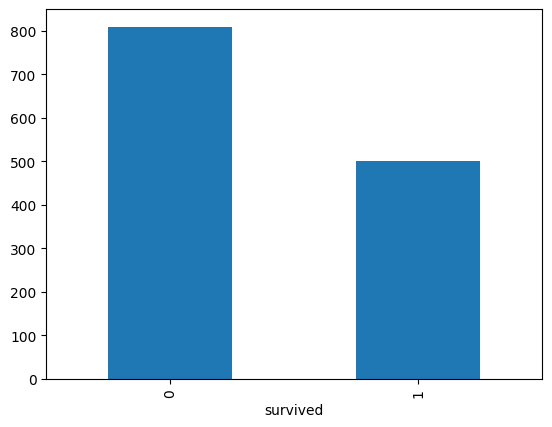

In [6]:
data['survived'].value_counts().plot(kind='bar')

Visualizamos esta distribución con un gráfico de barras:

In [7]:
data['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

### Análisis por Género

Analizamos la distribución de pasajeros por género (male/female):

<Axes: xlabel='sex'>

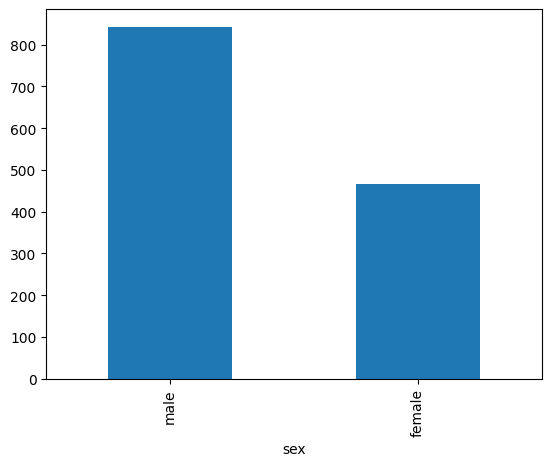

In [8]:
data['sex'].value_counts().plot(kind='bar')

Visualizamos la distribución con un gráfico de barras:

In [9]:
data[['sex', 'survived']].groupby('sex').mean()

,survived
sex,
female,0.727468
male,0.190985


Analizamos la tasa de supervivencia según el género. Agrupamos por género y calculamos la media de la columna 'survived' (1=sobrevivió, 0=no):

In [10]:
data['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

### Análisis por Clase de Pasajero (pclass)

Contamos la distribución de pasajeros por clase de boleto (1ra, 2da, 3ra clase):

In [11]:
data[['pclass', 'survived']].groupby('pclass').mean()

,survived
pclass,
1,0.619195
2,0.429603
3,0.255289


Calculamos la tasa de supervivencia por clase de pasajero:

In [12]:
data.groupby('pclass')['sex'].value_counts().sort_values(ascending=False)

pclass  sex   
3       male      493
        female    216
1       male      179
2       male      171
1       female    144
2       female    106
Name: count, dtype: int64

Cruzamos la información de clase y género para entender la distribución:

In [13]:
data[['sibsp', 'survived']].groupby('sibsp').mean().sort_values(by = 'survived', ascending=False)

,survived
sibsp,
1,0.510972
2,0.452381
0,0.346801
3,0.300000
4,0.136364
5,0.000000
8,0.000000


### Análisis por Familiares en el Barco

Analizamos la supervivencia según la cantidad de hermanos/cónyuge (sibsp) a bordo, ordenado por tasa de supervivencia:

In [14]:
data[['parch', 'survived']].groupby('parch').mean().sort_values(by = 'survived', ascending=False)

,survived
parch,
3,0.625000
1,0.588235
2,0.504425
0,0.335329
4,0.166667
5,0.166667
6,0.000000
9,0.000000


Analizamos la supervivencia según la cantidad de padres/hijos (parch) a bordo:

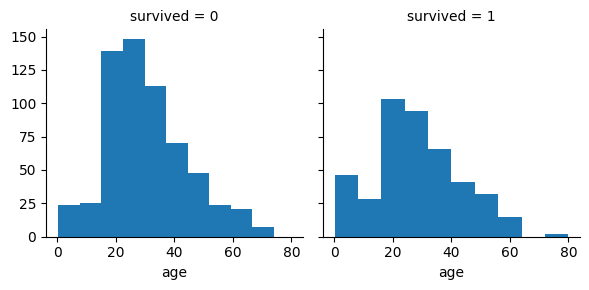

In [15]:
hist_agr = sns.FacetGrid(data, col='survived')
hist_agr.map(plt.hist, 'age', bins=10)

### Análisis por Edad

Visualizamos la distribución de edades usando FacetGrid de seaborn, separado por si sobrevivieron o no:

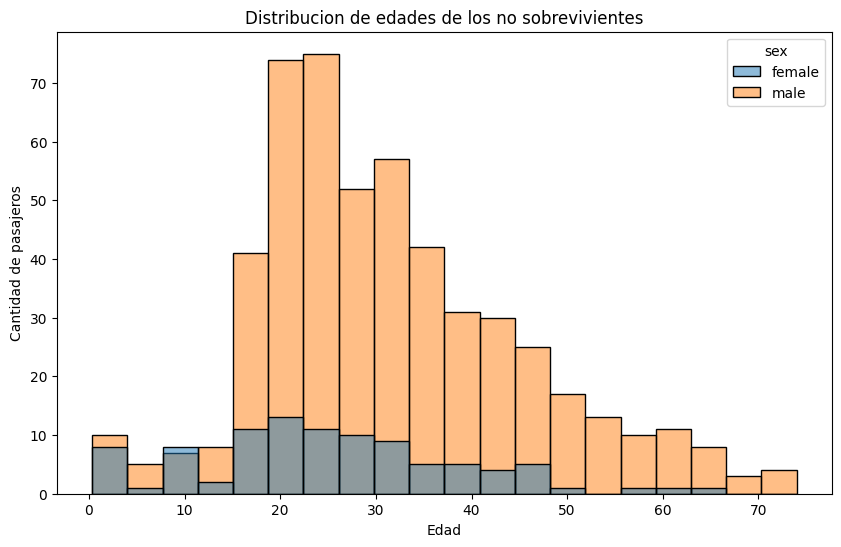

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data= data[data['survived'] == 0], x='age', hue='sex', bins=20, label='No sobrevivio')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribucion de edades de los no sobrevivientes')
plt.show()

Distribución de edades entre los NO sobrevivientes, separado por género:

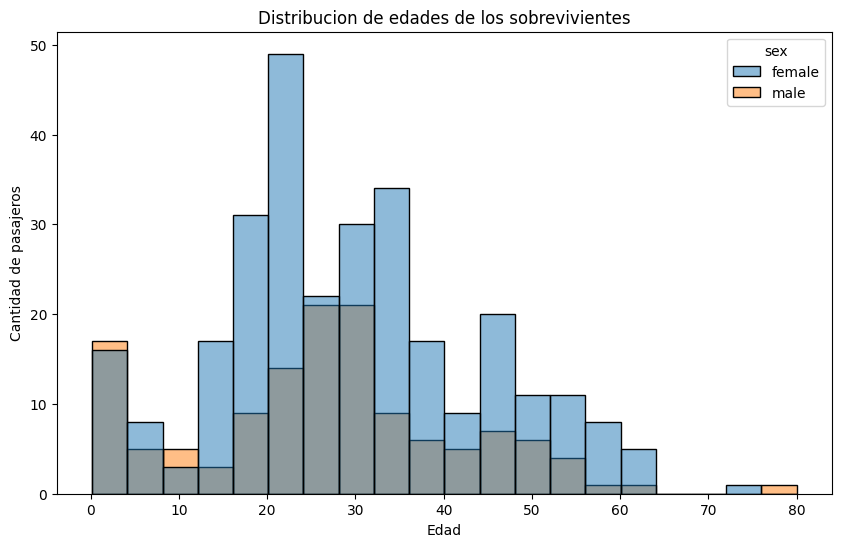

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data= data[data['survived'] == 1], x='age', hue='sex', bins=20, label='sobrevivientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribucion de edades de los sobrevivientes')
plt.show()

Distribución de edades entre los SOBREVIVIENTES, separado por género:

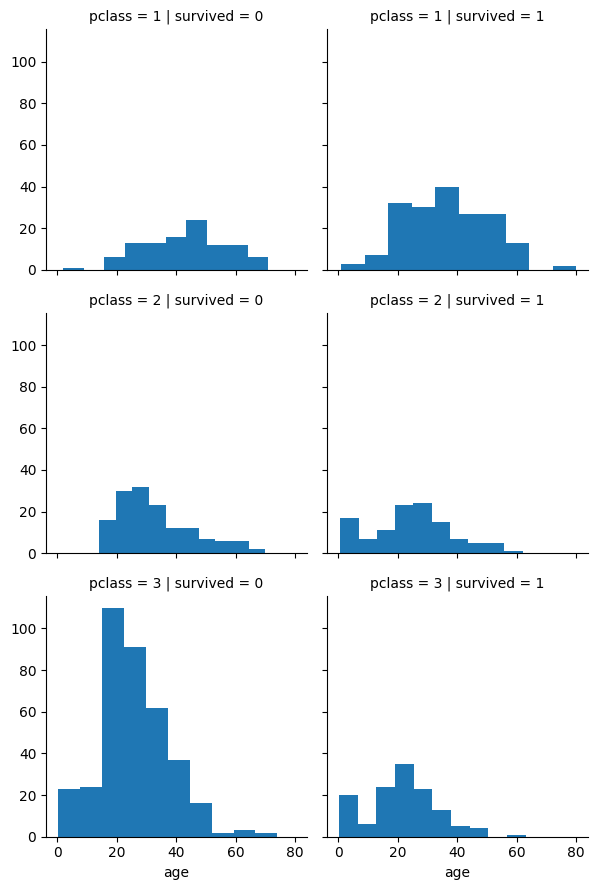

In [18]:
grid = sns.FacetGrid(data, col='survived', row='pclass')
grid.map(plt.hist, 'age', bins=10)
grid.add_legend()

Visualizamos la distribución de edades en una matriz de gráficos: filas para clase de pasajero, columnas para supervivencia:

## One-hot Encoder

In [19]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
ohe = one_hot_encoder.fit_transform(data[['sex']])
ohe = ohe.astype(int)

## 4. Preparación de Datos

### One-Hot Encoding para Variable Categórica

Las variables categóricas (como 'sex' que tiene valores 'male'/'female') necesitan convertirse en formato numérico.
Usamos OneHotEncoder para transformar 'sex' en columnas binarias (0 o 1):

In [20]:
one_hot_encoder_df = pd.DataFrame(ohe.toarray(), columns=one_hot_encoder.get_feature_names_out(['sex']))
one_hot_encoder_df

,sex_female,sex_male
0,1,0
1,0,1
2,1,0
3,0,1
4,1,0
...,...,...
1304,1,0
1305,1,0
1306,0,1
1307,0,1


Convertimos el resultado del encoder en un DataFrame de pandas:

In [21]:
data = pd.concat([data, one_hot_encoder_df], axis=1)
data

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,1
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,1,0
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,1,0
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0,1
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0,1


Concatenamos el DataFrame codificado con el original (eje 1 = agregar columnas):

In [22]:
data.drop('sex', axis=1, inplace=True)
data

,pclass,survived,name,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,"Allen, Miss. Elisabeth Walton",29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,1
2,1,0,"Allison, Miss. Helen Loraine",2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,1,0
1305,3,0,"Zabour, Miss. Thamine",NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,1,0
1306,3,0,"Zakarian, Mr. Mapriededer",26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0,1
1307,3,0,"Zakarian, Mr. Ortin",27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0,1


Eliminamos la columna 'sex' original ya que ahora tenemos las columnas codificadas:

In [23]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      1309 non-null   int64  
 1   survived    1309 non-null   int64  
 2   name        1309 non-null   object 
 3   age         1046 non-null   float64
 4   sibsp       1309 non-null   int64  
 5   parch       1309 non-null   int64  
 6   ticket      1309 non-null   object 
 7   fare        1308 non-null   float64
 8   cabin       295 non-null    object 
 9   embarked    1307 non-null   object 
 10  boat        486 non-null    object 
 11  body        121 non-null    float64
 12  home.dest   745 non-null    object 
 13  sex_female  1309 non-null   int64  
 14  sex_male    1309 non-null   int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 153.5+ KB


In [24]:
data.drop(['name', 'ticket', 'cabin', 'embarked', 'boat', 'body', 'home.dest'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      1309 non-null   int64  
 1   survived    1309 non-null   int64  
 2   age         1046 non-null   float64
 3   sibsp       1309 non-null   int64  
 4   parch       1309 non-null   int64  
 5   fare        1308 non-null   float64
 6   sex_female  1309 non-null   int64  
 7   sex_male    1309 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 81.9 KB


### Eliminación de Columnas Innecesarias

Eliminamos columnas que no aportarán información para el modelo de clasificación:
- 'name': Nombre del pasajero (no predice supervivencia)
- 'ticket': Número de ticket (no predictivo)
- 'cabin': Cabina (muchos valores faltantes)
- 'embarked': Puerto de embarque (no esencial)
- 'boat', 'body', 'home.dest': Información post-evento o incompleta

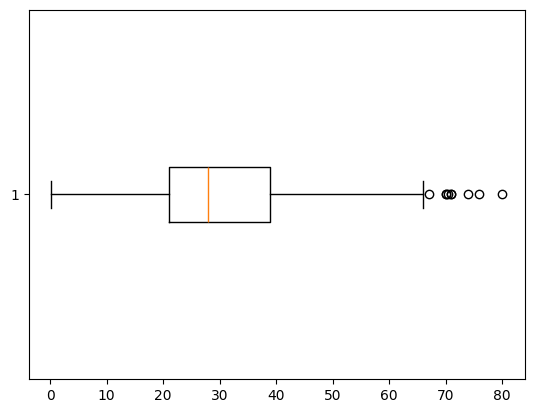

In [25]:
plt.boxplot(data['age'].dropna(), vert=False)
plt.show()

### Detección de Valores Atípicos (Outliers)

Visualizamos con boxplots la distribución de 'age' para detectar valores atípicos:

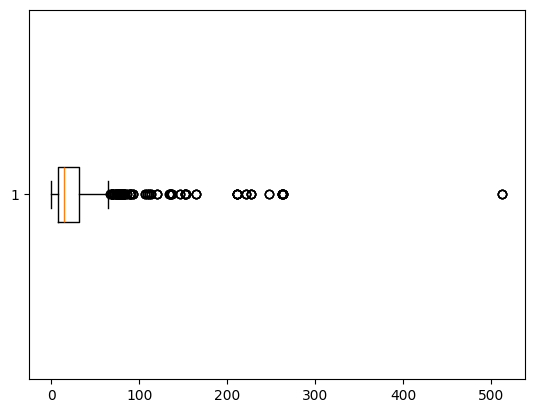

In [26]:
plt.boxplot(data['fare'].dropna(), vert=False)
plt.show()

Visualizamos también la distribución del 'fare' (tarifa):

In [27]:
data_copy = data.copy()

### Manejo de Valores Faltantes (NaN)

Creamos una copia del dataset para trabajar sin afectar el original:

In [28]:
data_copy['age'].fillna(data_copy['age'].mean(), inplace=True)
data_copy['fare'].fillna(data_copy['fare'].mean(), inplace=True)

C:\Users\david\AppData\Local\Temp\ipykernel_17960\3073613489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_copy['age'].fillna(data_copy['age'].mean(), inplace=True)
C:\Users\david\AppData\Local\Temp\ipykernel_17960\3073613489.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

Rellenamos los valores faltantes (NaN) con la media de cada columna:
- Valores NaN en 'age' se reemplazan con la edad promedio
- Valores NaN en 'fare' se reemplazan con la tarifa promedio

In [29]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      1309 non-null   int64  
 1   survived    1309 non-null   int64  
 2   age         1309 non-null   float64
 3   sibsp       1309 non-null   int64  
 4   parch       1309 non-null   int64  
 5   fare        1309 non-null   float64
 6   sex_female  1309 non-null   int64  
 7   sex_male    1309 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 81.9 KB


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = data_copy.drop('survived', axis=1)
y = data_copy['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Entrenamiento y Evaluación de Modelos

### División de Datos (Train-Test Split)

Separamos los datos en dos grupos:
- **X**: Variables predictoras (características) - todas las columnas excepto 'survived'
- **y**: Variable objetivo (target) - la columna 'survived'
- **80%** para entrenamiento, **20%** para prueba
- random_state=42 para reproducibilidad

In [32]:
print(data_copy.shape)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1309, 8)
(1047, 7) (262, 7)
(1047,) (262,)


Verificamos que la división de datos fue correcta:
- Dataset original: 1309 filas
- Entrenamiento: 80% (1047 filas aproximadamente)
- Prueba: 20% (262 filas aproximadamente)

In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=0, max_iter=400)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### Modelo 1: Regresión Logística

La regresión logística es un modelo lineal de clasificación que funciona bien como línea base.
Parámetros:
- random_state=0: Para reproducibilidad
- max_iter=400: Número máximo de iteraciones del optimizador

Entrenamos el modelo con los datos de entrenamiento:

In [34]:
y_pred = log_reg.predict(X_test)

Realizamos predicciones en el conjunto de prueba:

In [37]:
print('reales', y_test[:10].values, 'predichos', y_pred[:10])

reales [0 1 0 0 0 1 0 1 0 1] predichos [0 0 0 0 0 0 0 0 0 1]


Comparamos los valores reales vs predichos en los primeros 10 ejemplos:

In [38]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[127,  17],
       [ 43,  75]])

Creamos la matriz de confusión para evaluar el rendimiento:
- Diagonal principal: Predicciones correctas
- Fuera de diagonal: Errores

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

Importamos las métricas de evaluación del modelo:
- **Precision**: De los que predijimos como positivo, ¿cuántos fueron corretos?
- **Recall (Sensibilidad)**: De los positivos reales, ¿cuántos detectamos?
- **F1 Score**: Media armónica entre precision y recall
- **Score (Accuracy)**: Porcentaje general de aciertos

In [40]:
print('Precision:', precision_score(y_test, y_pred))
print('Memoria:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Score', round(log_reg.score(X_test, y_test)*100, 2))

Precision: 0.8152173913043478
Memoria: 0.635593220338983
F1 Score: 0.7142857142857143
Score 77.1


Calculamos y mostramos las métricas de rendimiento de la Regresión Logística:

## Arbol de decision

In [41]:
from sklearn.tree import DecisionTreeClassifier
cls = DecisionTreeClassifier()
cls.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Modelo 2: Árbol de Decisión

El árbol de decisión es un modelo no-paramétrico que crea reglas basadas en preguntas sobre las características.
Entrenamos el modelo con los datos de entrenamiento:

In [42]:
y_pred = cls.predict(X_test)
print('reales', y_test[:10].values, 'predichos', y_pred[:10])

reales [0 1 0 0 0 1 0 1 0 1] predichos [0 0 0 0 0 0 0 0 0 1]


Realizamos predicciones y comparamos con los valores reales:

In [43]:
confusion_matrix(y_test, y_pred)

array([[123,  21],
       [ 38,  80]])

Evaluamos la matriz de confusión:

In [44]:
print('Precision:', precision_score(y_test, y_pred))
print('Memoria:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Score', round(log_reg.score(X_test, y_test)*100, 2))

Precision: 0.7920792079207921
Memoria: 0.6779661016949152
F1 Score: 0.730593607305936
Score 77.1


Calculamos las métricas de rendimiento del Árbol de Decisión:

## Bosque aleatorio

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Modelo 3: Random Forest (Bosque Aleatorio)

Random Forest es un ensemble de múltiples árboles de decisión. Combina predicciones de varios árboles para mejorar la precisión.
Parámetros:
- n_estimators=100: Número de árboles en el bosque
- random_state=0: Para reproducibilidad

Entrenamos el modelo:

In [46]:
y_pred = rf_cls.predict(X_test)
print('reales', y_test[:10].values, 'predichos', y_pred[:10])


reales [0 1 0 0 0 1 0 1 0 1] predichos [0 0 0 0 0 0 0 0 0 1]


Realizamos predicciones con Random Forest:

In [47]:
confusion_matrix(y_test, y_pred)

array([[125,  19],
       [ 40,  78]])

Evaluamos la matriz de confusión de Random Forest:

In [48]:
print('Precision:', precision_score(y_test, y_pred))
print('Memoria:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Score', round(rf_cls.score(X_test, y_test)*100, 2))

Precision: 0.8041237113402062
Memoria: 0.6610169491525424
F1 Score: 0.7255813953488373
Score 77.48


Calculamos las métricas de rendimiento de Random Forest:

## KNeighbors

In [49]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Modelo 4: KNeighbors (K-Vecinos Más Cercanos)

KNeighbors es un modelo basado en instancias que predice la clase basándose en los k vecinos más cercanos.
Parámetros:
- n_neighbors=5: Considera los 5 vecinos más cercanos

Entrenamos el modelo y evaluamos su rendimiento:

In [50]:
y_pred = knn.predict(X_test)
print('reales', y_test[:10].values, 'predichos', y_pred[:10])
print(confusion_matrix(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Memoria:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Score', round(knn.score(X_test, y_test)*100, 2))

reales [0 1 0 0 0 1 0 1 0 1] predichos [0 0 0 0 0 0 0 0 0 1]
[[119  25]
 [ 59  59]]
Precision: 0.7023809523809523
Memoria: 0.5
F1 Score: 0.5841584158415841
Score 67.94


Realizamos predicciones con KNeighbors y calculamos todas las métricas de rendimiento en un solo paso:
- Comparamos primeros 10 predichos vs reales
- Matriz de confusión
- Precision, Recall, F1 Score y Accuracy

## Conclusiones

Se han entrenado y evaluado **4 modelos de clasificación** diferentes:

1. **Regresión Logística**: Modelo lineal, línea base para comparación
2. **Árbol de Decisión**: Modelo interpretable pero puede sufrir overfitting
3. **Random Forest**: Ensemble de árboles, generalmente mejor rendimiento
4. **KNeighbors**: Modelo basado en proximidad, sensible a la escala de características

### Métricas de Evaluación:
- **Precision**: ¿Qué porcentaje de predicciones positivas fueron correctas?
- **Recall**: ¿Qué porcentaje de casos positivos reales fueron detectados?
- **F1 Score**: Balance entre precision y recall
- **Accuracy**: Porcentaje general de predicciones correctas

Compara los resultados de cada modelo para determinar cuál funciona mejor para tus necesidades específicas.